<a href="https://colab.research.google.com/github/farnazcs/DFT-to-ML-Models/blob/main/RF_over_DFT.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score


In [2]:
# Load the dataset
data = pd.read_csv('atom_per_labeled.csv')

# Display the first 5 rows of the data
print(data.head())

# Check for any missing values
print(data.isnull().sum())


   Compounds  Energy per atom     Al   Mg        Si   Zn   Li   Ti        Ni  \
0  Ac2Al3Si1        -4.637168  0.500  0.0  0.166667  0.0  0.0  0.0  0.000000   
1  Ac1Al3Cu2        -4.308206  0.500  0.0  0.000000  0.0  0.0  0.0  0.000000   
2  Ac2Al6Ni4        -5.057031  0.500  0.0  0.000000  0.0  0.0  0.0  0.333333   
3  Ac1Al5Cu2        -4.229358  0.625  0.0  0.000000  0.0  0.0  0.0  0.000000   
4  Ac1Al5Ni2        -4.873648  0.625  0.0  0.000000  0.0  0.0  0.0  0.250000   

         Cu  ...    P    S   Sn   Th    V    W   Zr   Fe   Mn   Cr  
0  0.000000  ...  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  
1  0.333333  ...  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  
2  0.000000  ...  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  
3  0.250000  ...  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  
4  0.000000  ...  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  

[5 rows x 36 columns]
Compounds          0
Energy per atom    0
Al                 0
Mg                 

In [3]:
# Extract input features (X) and output variable (y)
elements = ['Al', 'Mg', 'Si', 'Zn', 'Li', 'Ti', 'Ni', 'Cu', 'Ag', 'As', 'Au', 'B', 'Bi', 'C', 'Ca',
            'Cd', 'Co', 'Ga', 'Hf', 'In', 'Mo', 'Nb', 'O', 'Pb', 'P', 'S', 'Sn', 'Th', 'V', 'W',
            'Zr', 'Fe', 'Mn', 'Cr']

X = data[elements]  # Input features
y = data.iloc[:, 1]  # Second column as output (formation energy per atom)

# Print the shape of input and output
print("Shape of X:", X.shape)
print("Shape of y:", y.shape)

Shape of X: (1080, 34)
Shape of y: (1080,)


In [4]:
# Split the data (90% training, 10% testing)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.1, random_state=42)

# Print the size of train and test sets
print("Training set size:", X_train.shape[0])
print("Test set size:", X_test.shape[0])


Training set size: 972
Test set size: 108


In [5]:
# Initialize the Random Forest Regressor
model = RandomForestRegressor(n_estimators=100, random_state=42)

# Train the model
model.fit(X_train, y_train)


RandomForestRegressor(random_state=42)

In [6]:
# Make predictions on the test set
y_pred = model.predict(X_test)


In [7]:
# Evaluate the model
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

# Print the metrics
print("Mean Squared Error (MSE):", mse)
print("Root Mean Squared Error (RMSE):", rmse)
print("R² Score:", r2)


Mean Squared Error (MSE): 0.5495065219999108
Root Mean Squared Error (RMSE): 0.7412870712483193
R² Score: 0.6353320897589328


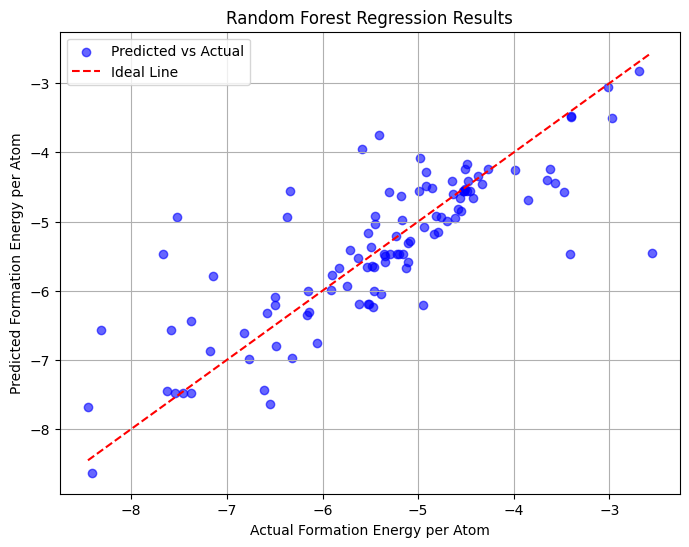

In [8]:
# Plot predicted vs actual values
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred, color='blue', alpha=0.6, label='Predicted vs Actual')
plt.plot([min(y_test), max(y_test)], [min(y_test), max(y_test)], color='red', linestyle='--', label='Ideal Line')
plt.xlabel('Actual Formation Energy per Atom')
plt.ylabel('Predicted Formation Energy per Atom')
plt.title('Random Forest Regression Results')
plt.legend()
plt.grid(True)
plt.show()


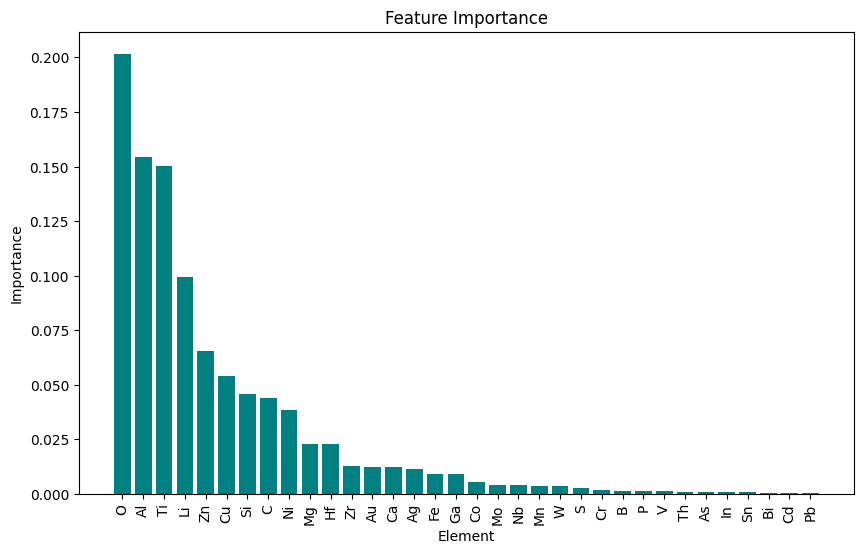

In [9]:
# Get feature importance
importances = model.feature_importances_
importance_df = pd.DataFrame({'Element': elements, 'Importance': importances})
importance_df = importance_df.sort_values(by='Importance', ascending=False)

# Plot feature importance
plt.figure(figsize=(10, 6))
plt.bar(importance_df['Element'], importance_df['Importance'], color='teal')
plt.xticks(rotation=90)
plt.xlabel('Element')
plt.ylabel('Importance')
plt.title('Feature Importance')
plt.show()
